Question: What is an accurate market value for a european futbol player given stats like goals, assists, minutes played, etc.  
Data Source: https://www.kaggle.com/datasets/kaanyorgun/european-top-leagues-player-stats-25-26
Techniques: Regression Modeling, Scaling, Encoding, Grid Search over multiple hyperparameters to find the most optimal choices. Ridge/Lasso regression. Feature Engineering.
Expected Results: Per-position modeling will be the most accurate.  League and goal-related features will affect market value the most for offensive players.  Saves and interceptions will affect market value for defensive players more.  The number of cards received and tackles will affect all players the least.  
Why: Modeling can be used to determine if a player is being under or over valued.  This can influence salary decisions which will maximize the team's expected performance while still meeting salary cap requirements.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_profiles = pd.read_csv('data/all_player_profiles.csv')
df_stats = pd.read_csv('data/all_player_stats.csv')

In [3]:
df_profiles.head()

,player_id,name,league,position,market_value
0,804508,Viktor Gyökeres,Premier League,F,61000000.0
1,934235,Bukayo Saka,Premier League,F,126000000.0
2,794839,Gabriel Jesus,Premier League,F,21000000.0
3,922573,Gabriel Martinelli,Premier League,F,42000000.0
4,836705,Kai Havertz,Premier League,F,48000000.0


In [4]:
df_stats.head()

,player_id,league,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
0,804508,Premier League,29,23,1907,11,0,9.3498,1.767505,6.572414,43,17,4,0,6,1,0
1,934235,Premier League,27,22,2001,6,3,6.9941,5.761951,7.214815,63,26,1,0,36,14,0
2,794839,Premier League,11,2,306,2,0,1.7605,0.203329,6.527273,14,9,2,0,4,2,0
3,922573,Premier League,25,9,852,1,3,3.3793,0.991020,6.616000,25,10,2,0,10,0,0
4,836705,Premier League,6,3,264,0,1,0.3077,0.097873,6.650000,5,1,0,0,3,0,0


In [5]:
df = pd.merge(df_profiles, df_stats, on='player_id', how='inner')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3725 entries, 0 to 3724
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3725 non-null   int64  
 1   name              3725 non-null   str    
 2   league_x          3725 non-null   str    
 3   position          3725 non-null   str    
 4   market_value      3660 non-null   float64
 5   league_y          3725 non-null   str    
 6   appearances       3725 non-null   int64  
 7   matches_started   3725 non-null   int64  
 8   minutes_played    3725 non-null   int64  
 9   goals             3725 non-null   int64  
 10  assists           3725 non-null   int64  
 11  expected_goals    3161 non-null   float64
 12  expected_assists  3701 non-null   float64
 13  rating            3725 non-null   float64
 14  total_shots       3725 non-null   int64  
 15  shots_on_target   3725 non-null   int64  
 16  yellow_cards      3725 non-null   int64  
 17  red_ca

In [7]:
mismatched_leagues = df[df['league_x'] != df['league_y']]
print(f"Rows with mismatched leagues: {len(mismatched_leagues)}")

Rows with mismatched leagues: 0


In [8]:
df = df.drop(columns=['league_y']).rename(columns={'league_x':'league'})

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3725 entries, 0 to 3724
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         3725 non-null   int64  
 1   name              3725 non-null   str    
 2   league            3725 non-null   str    
 3   position          3725 non-null   str    
 4   market_value      3660 non-null   float64
 5   appearances       3725 non-null   int64  
 6   matches_started   3725 non-null   int64  
 7   minutes_played    3725 non-null   int64  
 8   goals             3725 non-null   int64  
 9   assists           3725 non-null   int64  
 10  expected_goals    3161 non-null   float64
 11  expected_assists  3701 non-null   float64
 12  rating            3725 non-null   float64
 13  total_shots       3725 non-null   int64  
 14  shots_on_target   3725 non-null   int64  
 15  yellow_cards      3725 non-null   int64  
 16  red_cards         3725 non-null   int64  
 17  tackle

In [10]:
df = df.set_index('player_id')
df.shape

(3725, 19)

In [11]:
df.describe()

,market_value,appearances,matches_started,minutes_played,goals,assists,expected_goals,expected_assists,rating,total_shots,shots_on_target,yellow_cards,red_cards,tackles,interceptions,saves
count,3.660000e+03,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000,3161.000000,3.701000e+03,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000,3725.000000
mean,9.917490e+06,17.186309,12.404832,1115.761074,1.515168,1.062013,1.841740,1.101702e+00,6.718248,14.150604,4.876510,2.193020,0.114899,17.884832,9.383356,3.423087
std,1.656789e+07,8.668354,9.063707,768.761711,2.610213,1.644628,2.433426,1.360329e+00,0.636513,16.139484,6.635014,2.102133,0.344834,16.660214,9.990148,15.293558
min,2.300000e+04,1.000000,0.000000,1.000000,0.000000,0.000000,0.003200,9.300000e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.100000e+06,10.000000,4.000000,436.000000,0.000000,0.000000,0.360300,1.433916e-01,6.600000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000
50%,3.700000e+06,19.000000,11.000000,1038.000000,1.000000,0.000000,0.992300,6.322265e-01,6.741667,9.000000,2.000000,2.000000,0.000000,14.000000,6.000000,0.000000
75%,1.160000e+07,25.000000,20.000000,1755.000000,2.000000,2.000000,2.217400,1.530088e+00,6.906897,20.000000,7.000000,3.000000,0.000000,28.000000,15.000000,0.000000
max,2.180000e+08,31.000000,31.000000,2790.000000,31.000000,18.000000,24.383200,1.476492e+01,9.700000,117.000000,61.000000,12.000000,3.000000,96.000000,63.000000,138.000000


In [12]:
df['league'].value_counts()

league
LaLiga            515
Serie A           495
Premier League    477
Eredivisie        459
Liga Portugal     453
Ligue 1           447
Super Lig         442
Bundesliga        437
Name: count, dtype: int64

In [13]:
df['position'].value_counts()

position
M    1449
D    1223
F     781
G     272
Name: count, dtype: int64

In [14]:
df.isnull().sum()

name                  0
league                0
position              0
market_value         65
appearances           0
matches_started       0
minutes_played        0
goals                 0
assists               0
expected_goals      564
expected_assists     24
rating                0
total_shots           0
shots_on_target       0
yellow_cards          0
red_cards             0
tackles               0
interceptions         0
saves                 0
dtype: int64

In [15]:
# Drop name as it won't be used for modeling
df = df.drop(columns=['name'])

In [16]:
# Check if missing expected goals is related to position
df[df['expected_goals'].isna()]['position'].value_counts()

position
G    260
D    148
M    116
F     40
Name: count, dtype: int64

In [17]:
# Fill expected goals with per-position median.  This would be slightly more accurate than 
# a global median because goalies should have a lower exected goals value than forwards.
df['expected_goals'] = df.groupby('position')['expected_goals'].transform(
    lambda x: x.fillna(x.median())
)

In [18]:
# Check if missing expected assists is related to position
df[df['expected_assists'].isna()]['position'].value_counts()

position
F    10
D     9
M     5
Name: count, dtype: int64

In [19]:
# Fill exptected assists with per-position median for the same reason as above.
df['expected_assists'] = df.groupby('position')['expected_assists'].transform(
    lambda x: x.fillna(x.median())
)

In [20]:
# Drop rows with missing market value because this is our target. These rows are useless.
df = df.dropna(subset=['market_value'])

In [21]:
# Drop rows with less than 270 minutes played.  These players' stats will most likely introduce more noise than anything.
df = df[df['minutes_played'] >= 270]

In [22]:
df.shape

(3058, 18)

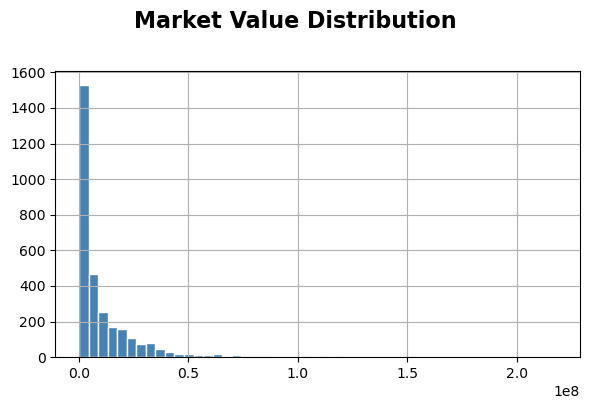

In [23]:
# Our target variable is skewed.  We will want to convert it to log before modeling.
df['market_value'].hist(figsize=(6,4), bins=50, edgecolor='white', color='steelblue')
plt.suptitle('Market Value Distribution', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

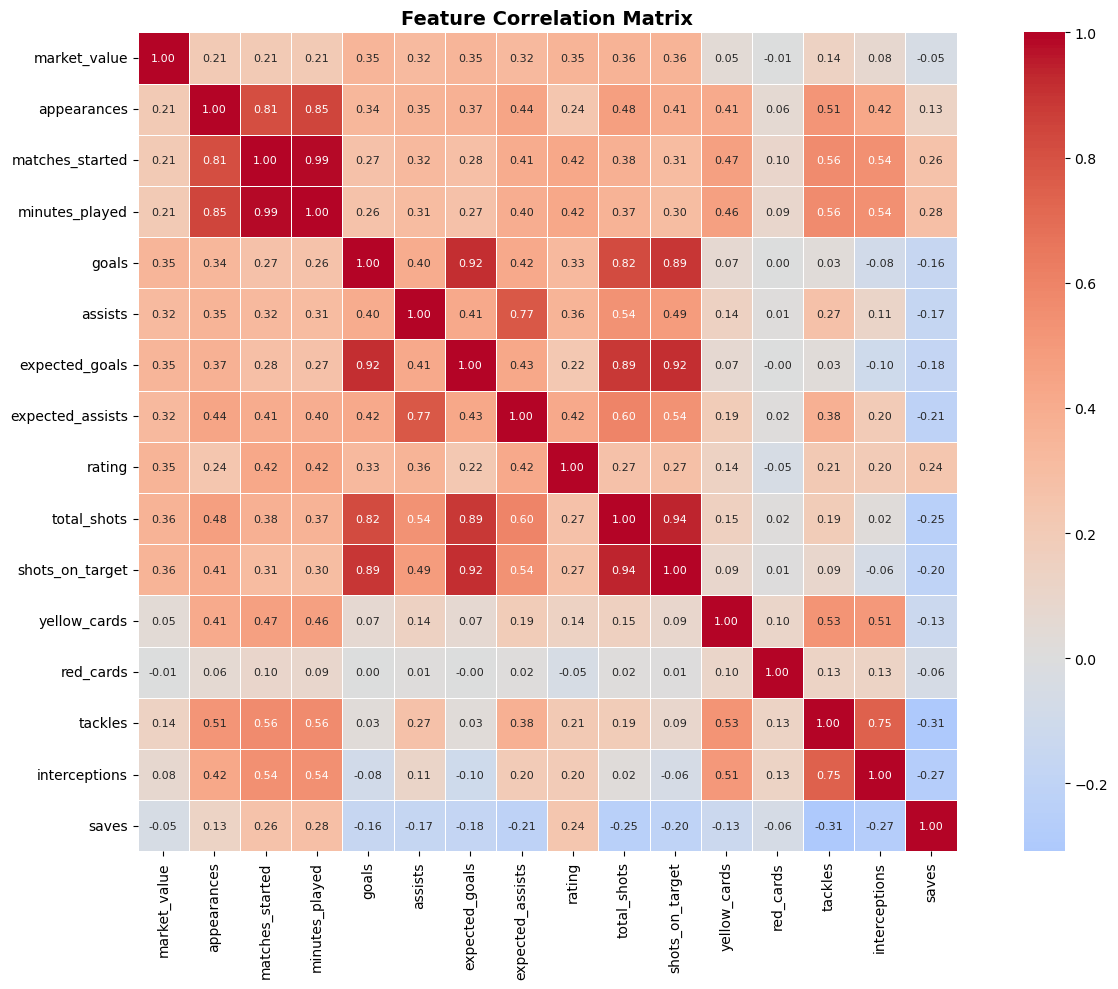

In [24]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size':8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# minutes_played is highly correlated with appearances and matches_started.  we'll drop them as minutes_played is more granular
df = df.drop(columns=['matches_started', 'appearances'])

In [26]:
# shots_on_target is highly correlated with goals, expected_goals, and total_shots.  we'll drop shots_on_target as the other
#  features are more important
# NOTE: expected_goals is also highly correlated with goals.  However, they are both important features from
#  a domain perspective.  Players who outperform their expected goals are probably worth more.  We'll keep both.
df = df.drop(columns=['shots_on_target'])

In [27]:
# Add a column for the log of market_value because the data for that column is skewed.
df['log_market_value'] = np.log1p(df['market_value'])

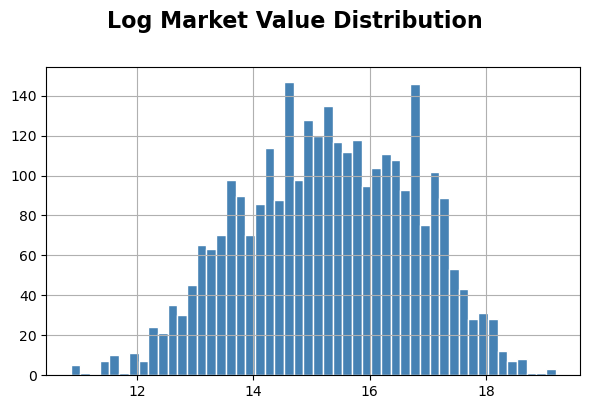

In [61]:
# Plot the log_market_value
df['log_market_value'].hist(figsize=(6,4), bins=50, edgecolor='white', color='steelblue')
plt.suptitle('Log Market Value Distribution', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/log_market_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Introduce per-90-minute features.  These will help distinguish players who had higher stats simply 
#  because they played longer. We could, instead, introduce log-value columns, but per-90 (or per-game)
#  is a common approach to sports-stats modeling.  
per_90_cols = [
    'goals', 'assists', 'expected_goals', 'expected_assists',
    'total_shots', 'tackles', 'interceptions', 'yellow_cards',
    'red_cards', 'saves'
]
for col in per_90_cols:
    df[f'{col}_per90'] = df[col]/(df['minutes_played']/90)

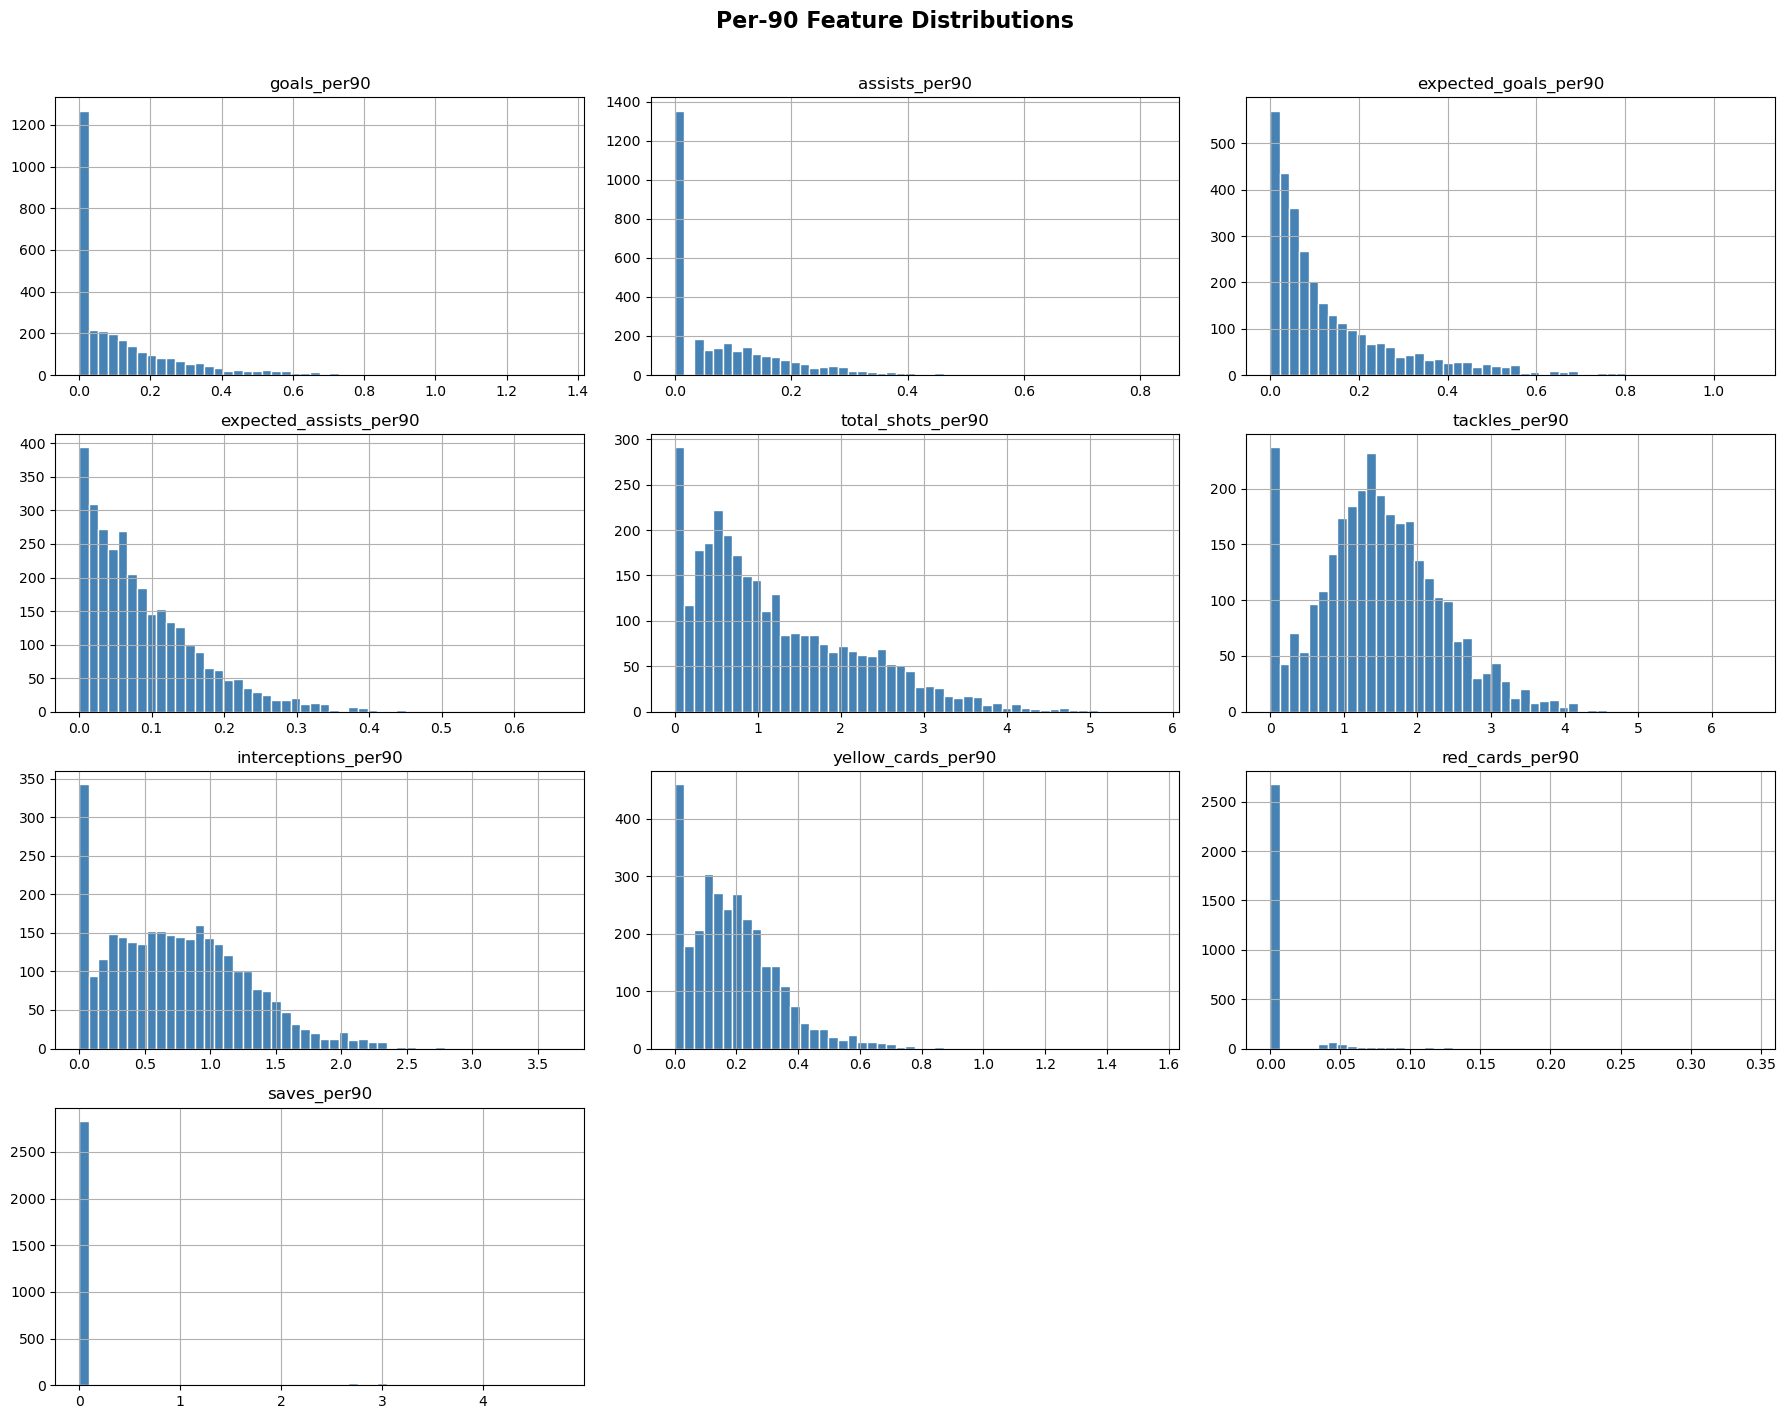

In [30]:
per_90_cols = [c for c in df.columns if c.endswith('_per90')]
df[per_90_cols].hist(figsize=(18,14), bins=50, edgecolor='white', color='steelblue')
plt.suptitle('Per-90 Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/per-90 feature distributions', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Drop columns that we've logged or converted to 90-minute versions
df = df.drop(columns=[
    'goals', 'assists', 'expected_goals', 'expected_assists',
    'total_shots', 'tackles', 'interceptions', 'yellow_cards',
    'red_cards', 'saves', 'market_value'])
df.columns.tolist()

['league',
 'position',
 'minutes_played',
 'rating',
 'log_market_value',
 'goals_per90',
 'assists_per90',
 'expected_goals_per90',
 'expected_assists_per90',
 'total_shots_per90',
 'tackles_per90',
 'interceptions_per90',
 'yellow_cards_per90',
 'red_cards_per90',
 'saves_per90']

In [32]:
# Check for outliers in our target
def flag_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)

outliers = flag_outliers(df, 'log_market_value')
print(f"Outliers found: {outliers.sum()}")
df = df[~outliers]
print(f"Rows remaining: {len(df)}")


Outliers found: 4
Rows remaining: 3054


In [33]:
# Separate our data into features and target
y = df['log_market_value']
X = df.drop(columns=['log_market_value'])

In [34]:
# Split columns by type
categorical_cols = ['league', 'position']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

In [35]:
# Split the data into train and test sets.  Build the column transformer for scaling and category encoding
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # This also shuffles the data before splitting

# Initialize results DF
results = pd.DataFrame(
    index=['Lasso', 'Ridge', 'XGBoost', 'RandomForest'],
    columns=['R^2', 'MAE', 'RMSE']
)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Create and train model
def fit_model(
    model, # The model to fit
    param_grid, # The parameters to search over with GridSearchCV
    model_name, # The name of the model (for logging and storing results)
    X_train_, # Local versions of data (for code re-use)
    X_test_,
    y_train_,
    y_test_,
    X, 
    y,
    results # The collection to add the results to
):
    preprocessor = ColumnTransformer([
        ('num', RobustScaler(), numerical_cols), # Use RobustScaler to reduce the influence of outliers
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])
    
    pipe = Pipeline([
        ('pre', preprocessor),
        ('model', model)
    ])
    
    # Use KFold so we shuffle before creating the k-fold splits
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        pipe, 
        param_grid, 
        cv=kfold, 
        scoring='r2', # R2 gives an indication of how the model explains variance
        n_jobs=-1 # Use all cpu cores to speed up search
    )
    grid.fit(X_train_, y_train_)

    # Calculate model metrics against the test set
    y_pred_log = grid.predict(X_test_)
    
    # Convert from log(market_value) back to market_value
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test_)
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

    results.loc[model_name, 'R^2'] = round(grid.best_score_, 3)
    results.loc[model_name, 'MAE'] = round(mae, 3)
    results.loc[model_name, 'RMSE'] = round(rmse, 3)
    
    return grid

In [37]:
# Lasso model
categorical_cols = ['league', 'position']
param_grid = {
    'model__alpha': [0.0001, 0.001, 0.01]
}
lasso = fit_model(Lasso(), param_grid, 'Lasso', 
                  X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {lasso.best_params_}")
results.loc[['Lasso']]

Best Parameters: {'model__alpha': 0.0001}


,R^2,MAE,RMSE
Lasso,0.518,7050816.161,13684362.821


In [38]:
# Ridge model
categorical_cols = ['league', 'position']
param_grid = {
    'model__alpha': [0.1, 1, 10]
}
ridge = fit_model(Ridge(), param_grid, 'Ridge',  
                  X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {ridge.best_params_}")
results.loc[['Ridge']]

Best Parameters: {'model__alpha': 1}


,R^2,MAE,RMSE
Ridge,0.518,7052740.593,13671180.27


In [39]:
# XGBoost model
from xgboost import XGBRegressor
categorical_cols = ['league', 'position']
param_grid = {
    'model__n_estimators': [100, 125, 150],
    'model__max_depth': [1, 2, 3],
    'model__learning_rate': [0.85, 0.1, 0.15],
    'model__subsample': [0.6, 0.7, 0.8]
}
xgboost = fit_model(XGBRegressor(random_state=42), param_grid, 'XGBoost', 
                    X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {xgboost.best_params_}")
results.loc[['XGBoost']]

Best Parameters: {'model__learning_rate': 0.15, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}


,R^2,MAE,RMSE
XGBoost,0.513,7278809.162,14469769.36


In [40]:
# Random Forest model
from sklearn.ensemble import RandomForestRegressor
categorical_cols = ['league', 'position']
param_grid = {
    'model__n_estimators': [550, 600, 650],
    'model__max_depth': [7, 10, 13],
    'model__min_samples_split': [30, 40, 50]
}
rf = fit_model(RandomForestRegressor(random_state=42), param_grid, 'RandomForest', 
               X_train, X_test, y_train, y_test, X, y, results)
print(f"Best Parameters: {rf.best_params_}")
results.loc[['RandomForest']]


Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 40, 'model__n_estimators': 600}


,R^2,MAE,RMSE
RandomForest,0.502,7306751.664,15531570.226


In [41]:
results

,R^2,MAE,RMSE
Lasso,0.518,7050816.161,13684362.821
Ridge,0.518,7052740.593,13671180.27
XGBoost,0.513,7278809.162,14469769.36
RandomForest,0.502,7306751.664,15531570.226


These results aren't great.  MAE of 7 million euros means that for a low-value player of 500k, our estimate is way off.  For a high-value player of 50M+ euros, we aren't too far off, though.  Per-position modeling may be more accurate as stats like `saves` is important for goalies, but not for `forwards`.

In [42]:
# Split our data by position and model each separately
from sklearn.preprocessing import RobustScaler

categorical_cols = ['league']

for pos in df['position'].unique():
    df_pos = df[df['position'] == pos]
    X_pos = df_pos.drop(columns=['log_market_value', 'position'])
    y_pos = df_pos['log_market_value']
    X_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(
        X_pos, y_pos, test_size=0.1, random_state=42
    )
    print(f"Training {pos} with {len(df_pos)} rows")
    
    results_pos = pd.DataFrame(
        index=['Lasso', 'Ridge', 'XGBoost'],
        columns=['R^2', 'MAE', 'RMSE']
    )
    # Train Lasso
    param_grid = {
        'model__alpha': [0.00001, 0.0001, 0.001, 0.1]
    }
    lasso_pos = fit_model(Lasso(), param_grid, 'Lasso', X_train_pos, X_test_pos, y_train_pos, y_test_pos, X_pos, y_pos, results_pos)
    print(f"Best Lasso Parameters: {lasso_pos.best_params_}")

    # Train Ridge
    param_grid = {
        'model__alpha': [0.1, 1, 10]
    }
    ridge_pos = fit_model(Ridge(), param_grid, 'Ridge',  X_train_pos, X_test_pos, y_train_pos, y_test_pos, X_pos, y_pos, results_pos)
    print(f"Best Ridge Parameters: {ridge_pos.best_params_}")

    param_grid = {
        'model__n_estimators': [25, 50, 100, 150, 200, 250],
        'model__max_depth': [1, 2, 3],
        'model__learning_rate': [0.85, 0.1, 0.15, 0.2],
        'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0]
    }
    xgboost_pos = fit_model(XGBRegressor(random_state=42), param_grid, 'XGBoost', X_train_pos, 
                            X_test_pos, y_train_pos, y_test_pos, X_pos, y_pos, results_pos)
    print(f"Best XGBoost Parameters: {xgboost_pos.best_params_}")

    print(results_pos)
    print()
    

Training F with 606 rows
Best Lasso Parameters: {'model__alpha': 0.0001}
Best Ridge Parameters: {'model__alpha': 0.1}
Best XGBoost Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 1, 'model__n_estimators': 200, 'model__subsample': 0.8}
           R^2          MAE          RMSE
Lasso    0.516  7689275.889  19826607.802
Ridge    0.516  7700422.352  19823383.379
XGBoost  0.499  8065106.361  20708480.695

Training M with 1182 rows
Best Lasso Parameters: {'model__alpha': 0.001}
Best Ridge Parameters: {'model__alpha': 1}
Best XGBoost Parameters: {'model__learning_rate': 0.15, 'model__max_depth': 1, 'model__n_estimators': 150, 'model__subsample': 0.9}
           R^2          MAE          RMSE
Lasso    0.563  6131941.591  14296305.724
Ridge    0.563  6138977.113  14282495.965
XGBoost  0.564  6690932.249  16220468.253

Training D with 1041 rows
Best Lasso Parameters: {'model__alpha': 0.001}
Best Ridge Parameters: {'model__alpha': 1}
Best XGBoost Parameters: {'model__learning_rate':

Per-position modeling is only slightly better for midfielders, and it's worse for other positions.  This is most likely due to the small data set size after splitting it into position subgroups.

In [43]:
# Get feature names after one-hot encoding
categorical_cols = ['league', 'position']
ohe_features = lasso.best_estimator_['pre'].transformers_[1][1].get_feature_names_out(categorical_cols)
all_features = numerical_cols + list(ohe_features)

# Build coefficient series sorted by absolute magnitude
lasso_coefs = pd.Series(
    lasso.best_estimator_['model'].coef_,
    index=all_features
).sort_values(key=abs, ascending=False)

print(lasso_coefs.to_string())

league_Eredivisie        -1.351452
league_Premier League     1.306214
red_cards_per90           1.236447
position_G                1.127179
league_Liga Portugal     -1.114255
league_Super Lig         -1.092128
saves_per90              -0.591264
rating                    0.512439
minutes_played            0.372148
league_Serie A            0.336774
position_F               -0.331865
total_shots_per90         0.330890
league_Bundesliga         0.264057
expected_goals_per90      0.151106
position_M               -0.105662
yellow_cards_per90       -0.095699
assists_per90             0.094531
interceptions_per90      -0.075849
goals_per90              -0.072628
tackles_per90             0.047185
expected_assists_per90    0.038122
league_LaLiga             0.009534
position_D                0.007227
league_Ligue 1           -0.000000


In [59]:
# Audit the most inaccurately modeled players

# Generate predictions for all players using the global Ridge model
y_pred_log = ridge.best_estimator_.predict(X)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y)

# Format the given value to be more readable
def format_value(val):
    if val >= 1_000_000:
        return f'{val/1_000_000:.1f}M'
    return f'{val/1_000:.1f}K'

# Calculate the percent difference between the predicted and actual market value
audit = df[['position', 'league']].copy()
audit['actual_value'] = y_actual.values
audit['predicted_value'] = y_pred
audit['difference'] = audit['predicted_value'] - audit['actual_value']
audit['percent_diff'] = (audit['difference'] / audit['actual_value']) * 100

audit['actual_value_formatted'] = audit['actual_value'].apply(format_value)
audit['predicted_value_formatted'] = audit['predicted_value'].apply(format_value)
audit['percent_diff_formatted'] = audit['percent_diff'].apply(lambda x: f'{x:+.1f}%')

# Join back with the original table that contains the player names
audit.index.name = 'player_id'
audit = audit.join(df_profiles[['player_id', 'name']].set_index('player_id'), how='left')

# Print results
display_cols = ['name', 'position', 'league', 'actual_value_formatted', 
                'predicted_value_formatted', 'percent_diff_formatted']
print("Most Undervalued Players (model predicts higher market_value than actual)")
print(audit.nlargest(15, 'percent_diff')[display_cols].to_string(index=False))

print()
print("Most Overvalued Players (model predicts lower market_value than actual)")
print(audit.nsmallest(15, 'percent_diff')[display_cols].to_string(index=False))

Most Undervalued Players (model predicts higher market_value than actual)
            name position         league actual_value_formatted predicted_value_formatted percent_diff_formatted
     Karl Darlow        G Premier League                 210.0K                     13.0M               +6096.6%
            Nenê        F  Liga Portugal                  52.0K                      3.2M               +6021.2%
 Marius Courcoul        D        Ligue 1                  53.0K                      2.6M               +4850.8%
 Stephan Zagadou        D        Ligue 1                  97.0K                      3.5M               +3532.6%
           Josan        M         LaLiga                 105.0K                      3.7M               +3387.8%
   Matías Dituro        G         LaLiga                 205.0K                      6.5M               +3057.5%
          Bebeto        D  Liga Portugal                  53.0K                      1.6M               +2827.4%
   Santi Cazorla      